## DETECCIÓN DE REGÍMENES DE RIESGO FINANCIERO
### CASO COLOMBIANO

#### LIBRERÍAS

In [35]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

#### DATOS

In [36]:
df = pd.read_excel("datos colombia.xlsx")

In [37]:
df.head()

,Fecha,Vol,Fx,Vix,Oil,ISE,Inf,RES,I_long
0,2011-09-01,-0.030772,0.082031,0.3586,-0.111231,0.485780,0.31,0.002437,-0.9422
1,2011-10-01,0.015196,-0.033723,-0.3026,0.064076,0.404502,0.19,0.009401,-0.4773
2,2011-11-01,-0.034762,0.045098,-0.0721,0.008724,0.337870,0.14,-0.004584,-0.0124
3,2011-12-01,0.031988,-0.006981,-0.1583,-0.028823,0.298799,0.42,-0.008853,-0.0006
4,2012-01-01,-0.003711,-0.068588,-0.1692,0.032976,0.307507,0.73,0.006746,0.0208


#### LIMPIEZA

In [38]:
# Convertir fecha
df["Fecha"] = pd.to_datetime(df["Fecha"])

# Ordenar cronológicamente
df = df.sort_values("Fecha")

# Eliminar duplicados
df = df.drop_duplicates()

# Eliminar valores faltantes
df = df.dropna()

# Reiniciar índices
df = df.reset_index(drop=True)

#### CREACIÓN DE REGÍMENES

In [39]:
# Percentiles
p33 = df["Vol"].quantile(0.33)
p66 = df["Vol"].quantile(0.66)

# Función clasificación
def classify_regime(vol):

    if vol < p33:
        return 0  # Estabilidad

    elif vol < p66:
        return 1  # Estrés moderado

    else:
        return 2  # Crisis / alta tensión

# Variable objetivo
df["Regime"] = df["Vol"].apply(classify_regime)

In [40]:
df.head()

,Fecha,Vol,Fx,Vix,Oil,ISE,Inf,RES,I_long,Regime
0,2011-09-01,-0.030772,0.082031,0.3586,-0.111231,0.485780,0.31,0.002437,-0.9422,0
1,2011-10-01,0.015196,-0.033723,-0.3026,0.064076,0.404502,0.19,0.009401,-0.4773,1
2,2011-11-01,-0.034762,0.045098,-0.0721,0.008724,0.337870,0.14,-0.004584,-0.0124,0
3,2011-12-01,0.031988,-0.006981,-0.1583,-0.028823,0.298799,0.42,-0.008853,-0.0006,2
4,2012-01-01,-0.003711,-0.068588,-0.1692,0.032976,0.307507,0.73,0.006746,0.0208,1


#### VARIABLES EXPLICATIVAS

In [41]:
features = [

    "Fx",
    "Vix",
    "Oil",
    "ISE",
    "Inf",
    "RES",
    "I_long"
]

X = df[features]

y = df["Regime"]

#### ESTANDARIZACIÓN

In [42]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Convertir nuevamente a DataFrame
X_scaled = pd.DataFrame(

    X_scaled,

    columns=features,

    index=df.index
)

#### TRAIN / TEST SPLIT TEMPORAL

In [43]:
X_train, X_test, y_train, y_test = train_test_split(

    X_scaled,
    y,

    test_size=0.20,

    shuffle=False
)

#### MODELO RANDOM FOREST

In [44]:
model = RandomForestClassifier(

    n_estimators=500,

    max_depth=10,

    min_samples_split=10,

    min_samples_leaf=5,

    class_weight="balanced",

    random_state=42
)

# Entrenamiento
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10,
                       min_samples_leaf=5, min_samples_split=10,
                       n_estimators=500, random_state=42)

#### PREDICCIONES

In [45]:
predictions = model.predict(X_test)

#### MÉTRICAS DE EVALUACIÓN Y RESULTADOS DEL MODELO

In [46]:
print("\n===================================")
print("RESULTADOS DEL MODELO")
print("===================================\n")


# Accuracy
accuracy = accuracy_score(y_test, predictions)

# Precision
precision = precision_score(
    y_test,
    predictions,
    average="weighted"
)

# Recall
recall = recall_score(
    y_test,
    predictions,
    average="weighted"
)

# F1 Score
f1 = f1_score(
    y_test,
    predictions,
    average="weighted"
)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")


RESULTADOS DEL MODELO

Accuracy : 0.6286
Precision: 0.6743
Recall   : 0.6286
F1-Score : 0.6351


#### REPORTE CLASIFICACIÓN

In [47]:
print("\n===================================")
print("REPORTE DE CLASIFICACIÓN")
print("===================================\n")

print(classification_report(
    y_test,
    predictions
))



REPORTE DE CLASIFICACIÓN

              precision    recall  f1-score   support

           0       0.50      0.80      0.62         5
           1       0.53      0.62      0.57        13
           2       0.83      0.59      0.69        17

    accuracy                           0.63        35
   macro avg       0.62      0.67      0.63        35
weighted avg       0.67      0.63      0.64        35



#### MATRIZ DE CONFUSIÓN

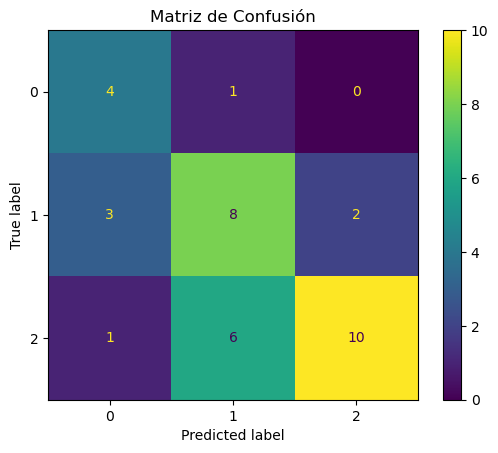

In [48]:
cm = confusion_matrix(
    y_test,
    predictions
)

disp = ConfusionMatrixDisplay(

    confusion_matrix=cm
)

disp.plot()

plt.title("Matriz de Confusión")

plt.show()


#### IMPORTANCIA DE VARIABLES

In [49]:
importance = pd.DataFrame({

    "Variable": features,

    "Importancia": model.feature_importances_
})

importance = importance.sort_values(

    by="Importancia",

    ascending=False
)

print("\n===================================")
print("IMPORTANCIA DE VARIABLES")
print("===================================\n")

print(importance)



IMPORTANCIA DE VARIABLES

  Variable  Importancia
0       Fx     0.243967
2      Oil     0.222590
3      ISE     0.129739
1      Vix     0.106223
6   I_long     0.104045
5      RES     0.101292
4      Inf     0.092145


#### GRÁFICO IMPORTANCIA VARIABLES

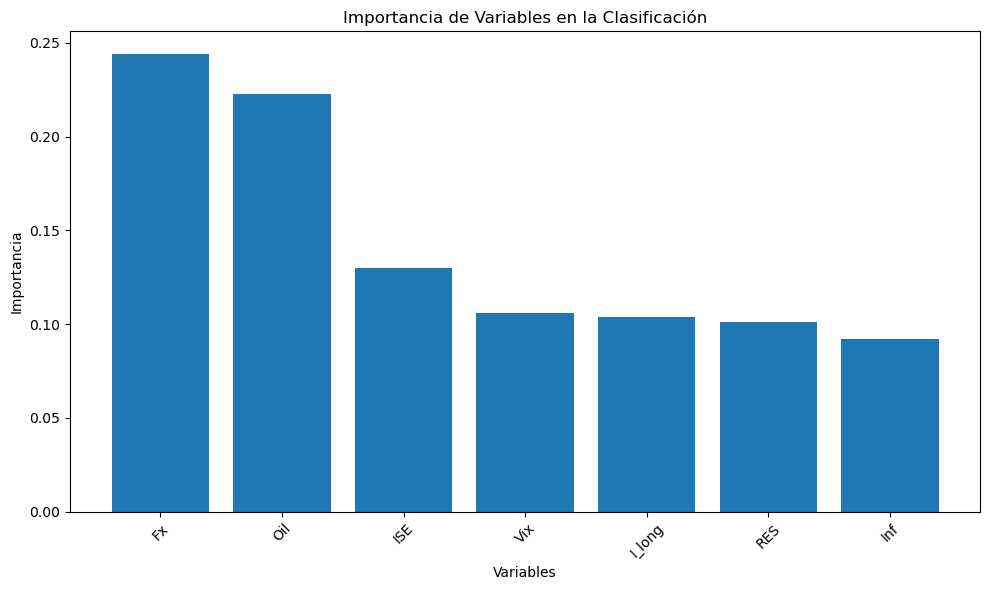

In [50]:
plt.figure(figsize=(10,6))

plt.bar(

    importance["Variable"],

    importance["Importancia"]
)

plt.title(
    "Importancia de Variables en la Clasificación"
)

plt.xlabel("Variables")

plt.ylabel("Importancia")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()


#### VISUALIZACIÓN DE REGÍMENES

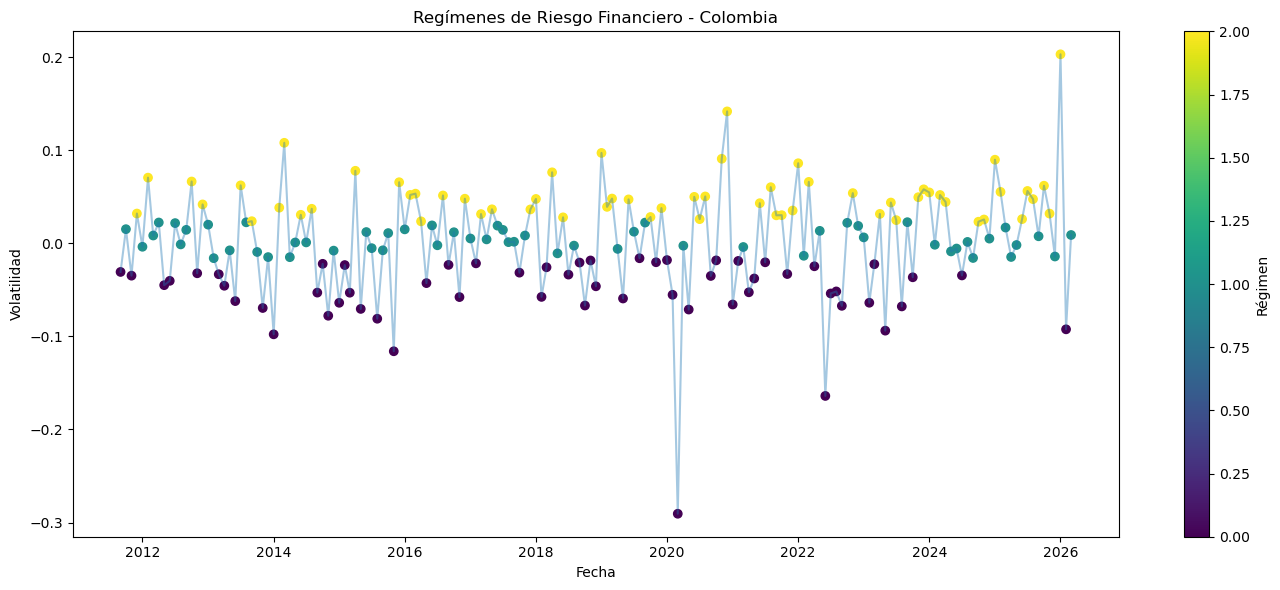

In [51]:
plt.figure(figsize=(14,6))

scatter = plt.scatter(

    df["Fecha"],

    df["Vol"],

    c=df["Regime"],

    cmap="viridis"
)

plt.plot(

    df["Fecha"],

    df["Vol"],

    alpha=0.4
)

plt.title(
    "Regímenes de Riesgo Financiero - Colombia"
)

plt.xlabel("Fecha")

plt.ylabel("Volatilidad")

plt.colorbar(
    scatter,
    label="Régimen"
)

plt.tight_layout()

plt.show()


#### PROBABILIDADES DE CRISIS

In [52]:
probabilities = model.predict_proba(X_test)

# Probabilidad régimen crisis (2)
crisis_prob = probabilities[:, 2]

# DataFrame resultados
results = pd.DataFrame({

    "Fecha": df.iloc[-len(X_test):]["Fecha"],

    "Prob_Crisis": crisis_prob,

    "Regime_Real": y_test.values,

    "Regime_Pred": predictions
})


#### GRÁFICO PROBABILIDAD DE CRISIS

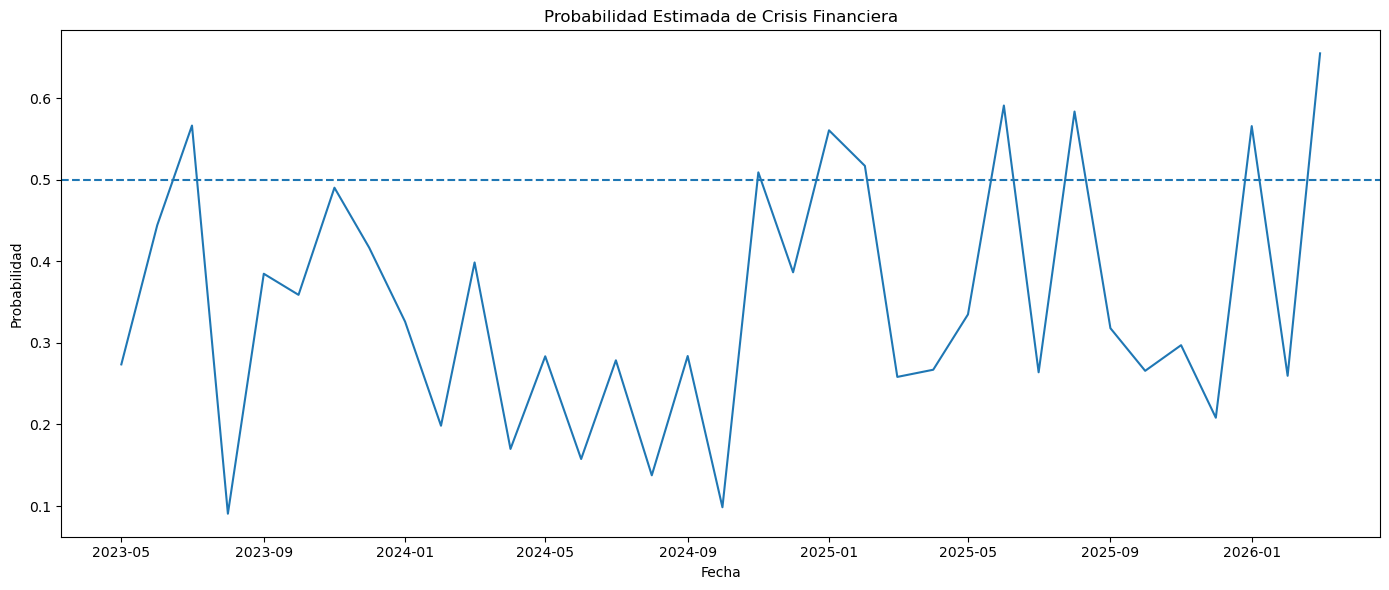

In [53]:
plt.figure(figsize=(14,6))

plt.plot(

    results["Fecha"],

    results["Prob_Crisis"]
)

plt.axhline(

    y=0.5,

    linestyle="--"
)

plt.title(
    "Probabilidad Estimada de Crisis Financiera"
)

plt.xlabel("Fecha")

plt.ylabel("Probabilidad")

plt.tight_layout()

plt.show()

#### EXPORTAR RESULTADOS

Opcional

In [ ]:
results.to_excel(

    "resultados_regimenes.xlsx",

    index=False
)

importance.to_excel(

    "importancia_variables.xlsx",

    index=False
)

print("\n===================================")
print("ARCHIVOS EXPORTADOS")
print("===================================\n")

print("resultados_regimenes.xlsx")
print("importancia_variables.xlsx")
